In [1]:
import matplotlib.pyplot as plt
import numpy as np
import perceval as pcvl
import sklearn.svm
import torch
from tqdm import tqdm

import merlin
from merlin.datasets import iris

In [2]:
class result():
    def __init__(self, g, var_FQK, var_RBF, var_RBF_order_2, F,eta_max, ROC_AUC, expressivity):
        self.var_FQK = var_FQK
        self.var_RBF = var_RBF
        self.var_RBF_order_2 = var_RBF_order_2
        self.g = g
        self.F = F
        self.eta_max = eta_max
        self.ROC_AUC = ROC_AUC
        self.expressivity = expressivity

In [3]:
feature_map = merlin.FeatureMap.simple(input_size=4)  # n_modes = input_size + 1 = 5
fidelity_kernel = merlin.FidelityKernel(
    feature_map=feature_map,
    input_state=[1, 0, 1, 0, 1],  # alternating photons for 5 modes
    computation_space=merlin.ComputationSpace.FOCK,
)

train_features, train_labels, train_metadata = iris.get_data_train()
test_features, test_labels, test_metadata = iris.get_data_test()

assert len(train_features) == len(train_labels)
assert len(test_features) == len(test_labels)


# Filter training set to only keep first two labels
binary_train_features = []
binary_train_labels = []
for i in range(len(train_features)):
    if train_labels[i] > 1:
        continue
    else:
        binary_train_features.append(train_features[i])
        binary_train_labels.append(train_labels[i])

# Filter test set to only keep first two labels
binary_test_features = []
binary_test_labels = []
for i in range(len(test_features)):
    if test_labels[i] > 1:
        continue
    else:
        binary_test_features.append(test_features[i])
        binary_test_labels.append(test_labels[i])

# Convert data to PyTorch tensors
# 1-D labels for the fidelity kernel method
X_train = torch.FloatTensor(np.array(binary_train_features))
y_train_1D = torch.LongTensor(np.array(binary_train_labels))
X_test = torch.FloatTensor(np.array(binary_test_features))
y_test_1D = torch.LongTensor(np.array(binary_test_labels))

# Convert 1-dimensional labels to 2 dimensional one hot vectors
# For the VQC that uses Binary Cross Entropy Loss (BCELoss)
# y_train_one_hot = torch.nn.functional.one_hot(y_train_1D, num_classes=2)
# y_test_one_hot = torch.nn.functional.one_hot(y_test_1D, num_classes=2)

print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")
print(f"Features: {X_train.shape[1]}")
print(f"Classes: {len(torch.unique(y_train_1D))}")
#print(f"All test labels: {y_test_1D}")
#print(f"All test labels (one hot): \n{y_test_one_hot}")

# Convert one hot vectors from long to float
# y_train = y_train_one_hot.float()
# y_test = y_test_one_hot.float()

Training samples: 81
Test samples: 19
Features: 4
Classes: 2


In [4]:
def matrix_sqrt(A): 
    """ Calcule la racine carrée matricielle d'une matrice symétrique semi-définie positive. """ 
    # Décomposition en valeurs propres (A = V * L * V^T) 
    L, V = torch.linalg.eigh(A)
    # Parfois, les erreurs de précision numérique créent des valeurs propres 
    # très légèrement négatives (ex: -1e-15). On les force à être positives ou nulles. 
    L = torch.clamp(L, min=0.0) 
    # Reconstruction : V * sqrt(L) * V^T 
    return V @ torch.diag(torch.sqrt(L)) @ V.T

def calculate_g(K1, K2): 
    """ Calcule g(K1, K2) avec lambda = 0. """ 
    # 1. Calcul de l'inverse de K2
    # Utilisation de pseudo-inverse (pinv) est plus sûr que inv()
    # car une matrice de noyau (K2) peut avoir un déterminant proche de 0. 
    K2_inv = torch.linalg.pinv(K2)
    # 2. Calcul de la racine carrée matricielle de K1 
    sqrt_K1 = matrix_sqrt(K1) 
    # 3. Produit matriciel central : sqrt(K1) @ K2^-1 @ sqrt(K1) 
    inner_matrix = sqrt_K1 @ K2_inv @ sqrt_K1 
    # 4. Norme spectrale (la plus grande valeur singulière, équivalente à ord=2) 
    spectral_norm = torch.linalg.matrix_norm(inner_matrix, ord=2) 
    # 5. Racine carrée finale de la formule 
    g = torch.sqrt(spectral_norm) 
    return g

def calculate_eta_max(K):
    L,V = torch.linalg.eigh(K)
    eta_max = L[-1]
    return eta_max

def calculate_kernel_distance_F(K_C, K_Q):
   """
   Calcule F(K_C, K_Q), la distance relative de Frobenius entre deux matrices de noyau.
   K_C : Tenseur PyTorch représentant la matrice de noyau classique.
   K_Q : Tenseur PyTorch représentant la matrice de noyau quantique.
   """
   # 1. Calcul du numérateur : Norme de Frobenius de la différence
   numerateur = torch.linalg.matrix_norm(K_C - K_Q, ord='fro')

   # 2. Calcul du dénominateur : Norme de Frobenius de K_Q
   denominateur = torch.linalg.matrix_norm(K_Q, ord='fro')

   # 3. Ratio final
   F = numerateur / denominateur

   return F

def calculate_expressivity(K):
    return 0

In [5]:
def train(X_train, y_train_1D, X_test, y_test_1D, bandwidth = 1.0, n_modes = -1, redundancy = False):

    X_train = X_train * bandwidth
    X_test = X_test * bandwidth

    if n_modes == -1:
        n_modes = X_train.shape[1] + 1
    if n_modes < X_train.shape[1] + 1:
        raise ValueError(f"n_modes must be at least {X_train.shape[1] + 1} for the given input size.")


    builder = merlin.CircuitBuilder(n_modes=n_modes)
    builder.add_entangling_layer(trainable=True, model="mzi", name="left")
    builder.add_angle_encoding(modes=[i for i in range(X_train.shape[1])], name="phi")
    builder.add_entangling_layer(trainable=True, model="mzi", name="right")

    feature_map = merlin.FeatureMap.simple(input_size=X_train.shape[1])  # n_modes = input_size + 1 = 5
    fidelity_kernel = merlin.FidelityKernel(
        feature_map=feature_map,
        input_state=[1 - (i % 2) for i in range(n_modes)],  # alternating photons for n_modes
        computation_space=merlin.ComputationSpace.FOCK,
    )

    svc = sklearn.svm.SVC(kernel="precomputed")

    K_train = fidelity_kernel(X_train)
    K_test = fidelity_kernel(X_test, X_train)


    svc.fit(K_train.detach().numpy(), y_train_1D.detach().numpy())
    test_accuracy = svc.score(K_test.detach().numpy(), y_test_1D.detach().numpy())

    #Calcul du kernel RBF
    distances = torch.cdist(X_train, X_train, p=2)
    distances_carré = distances ** 2
    K_rbf = torch.exp(-distances_carré)

    #Calcul du kernel RBF ordre 2
    distances = torch.cdist(X_train, X_train, p=2)
    z = distances ** 2
    K_rbf_order_2 = 1.0 - z + 0.5*(z**2)


    F = calculate_kernel_distance_F(K_train, K_rbf)
    eta_max = calculate_eta_max(K_train)
    ROC_AUC = sklearn.metrics.roc_auc_score(y_test_1D.detach().numpy(), svc.decision_function(K_test.detach().numpy()))

    return result(calculate_g(K_train,K_rbf).item(), K_train.var(correction=False).item(), K_rbf.var(correction=False).item(), K_rbf_order_2.var(correction=False).item(), F.item(), eta_max.item(), ROC_AUC, calculate_expressivity(K_train))


In [6]:
x,y_g,y_FQK,y_RBF,y_RBF_order_2,y_F,y_eta_max,y_ROC_AUC = [],[],[],[],[],[],[],[]

for i in np.logspace(-3, 3, 60):
    res = train(X_train, y_train_1D, X_test, y_test_1D, bandwidth=i)
    y_g.append(res.g)
    y_FQK.append(res.var_FQK)
    y_RBF.append(res.var_RBF)
    y_RBF_order_2.append(res.var_RBF_order_2)
    y_F.append(res.F)
    y_eta_max.append(res.eta_max)
    y_ROC_AUC.append(res.ROC_AUC)
    x.append(i)
    print(i)

0.001
0.0012638482029342984
0.001597312280060254
0.002018760254679039
0.0025514065200312875
0.0032245905452963947
0.004075392965871778
0.005150678076168122
0.00650967523045817
0.008227241341700473
0.0103979841848149
0.013141473626117567
0.016608827826277157
0.020991037201085545
0.026529484644318972
0.03352924149249558
0.04237587160604064
0.05355666917706899
0.06768750009458535
0.08554672535565684
0.10811807510766078
0.13664483492953258
0.1726983290659436
0.21826447283974873
0.2758531617629184
0.34863652276780877
0.44062364277735727
0.5568813990945273
0.7038135554931562
0.8895134973108236
1.1242100350620874
1.4208308325339223
1.795714494371641
2.269510536694671
2.868316813342012
3.6251170499885355
4.581597669054491
5.790443980602489
7.318242219076182
9.249147277217336
11.689518164985776
14.773776525985127
18.671810912919206
23.598334667821938
29.82471286216894
37.69390975388364
47.639380104013405
60.20894493336138
76.09496685459884
96.17248711152965
121.54742500762885
153.61749466718297

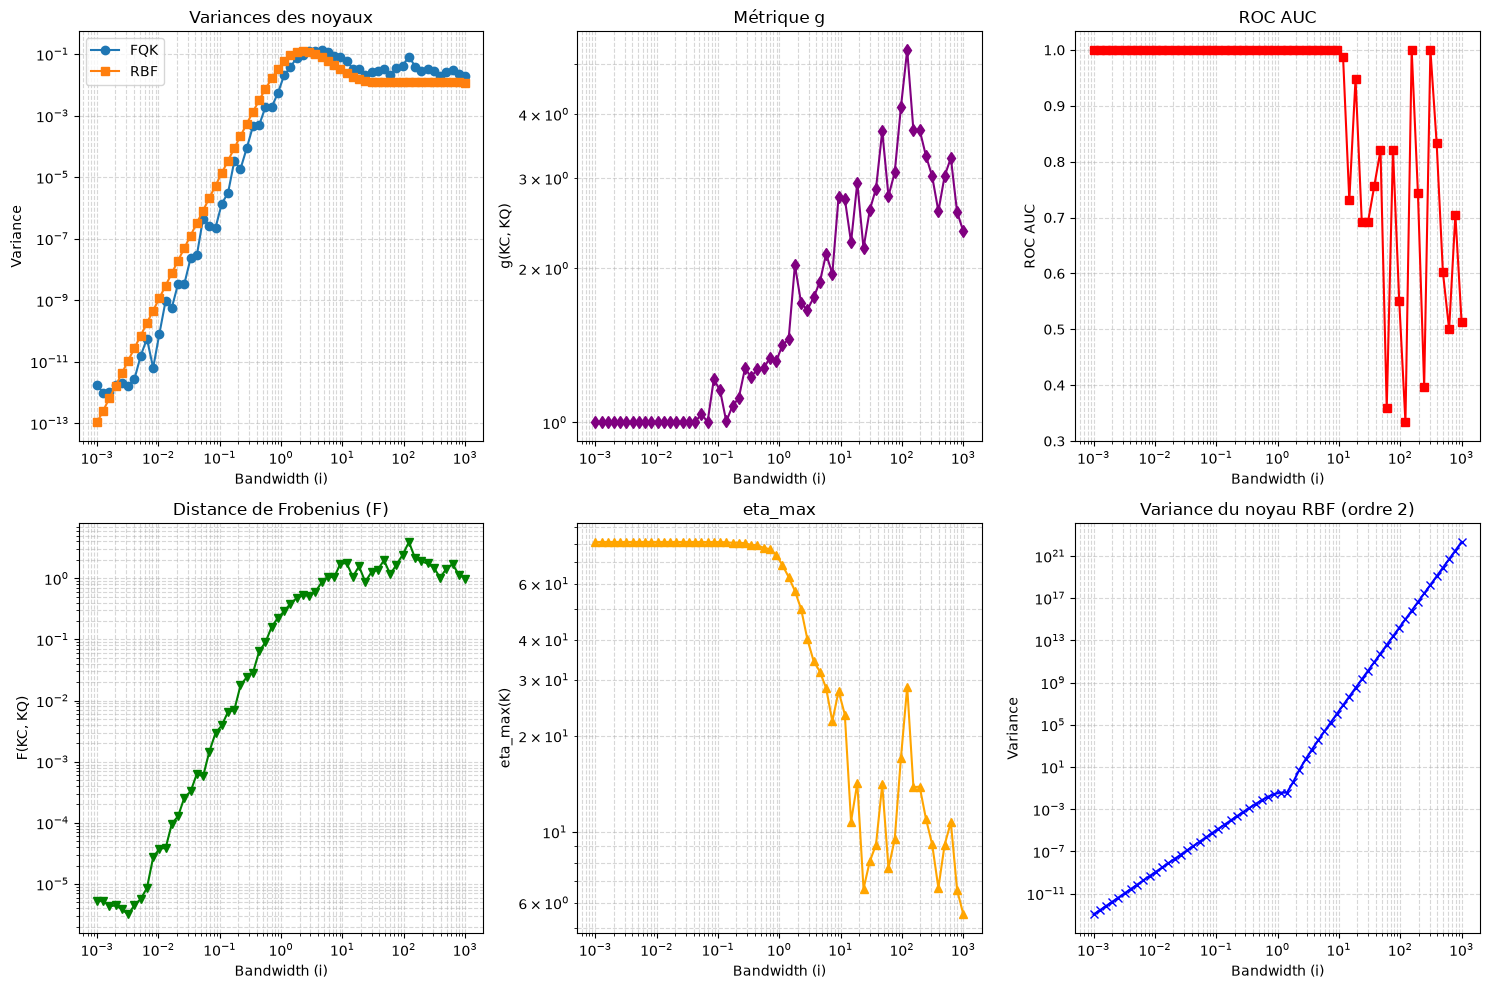

In [7]:
# Création de la figure et d'une grille de 6 graphiques
# figsize=(15, 5) permet d'avoir une image bien large
fig, axes = plt.subplots( 2, 3, figsize=(15, 10))

# ==========================================
# Subplot 1 : Les Variances (FQK et RBF)
# ==========================================
axes[0,0].loglog(x, y_FQK, label="FQK", marker='o', linestyle='-')
axes[0,0].loglog(x, y_RBF, label="RBF", marker='s', linestyle='-')

axes[0,0].set_title("Variances des noyaux")
axes[0,0].set_xlabel("Bandwidth (i)")
axes[0,0].set_ylabel("Variance")
axes[0,0].legend() # Affiche la légende pour différencier les 3 courbes
axes[0,0].grid(True, which="both", ls="--", alpha=0.5) # Ajoute une grille lisible en log

# ==========================================
# Subplot 2 : La métrique g
# ==========================================
axes[0,1].loglog(x, y_g, color='purple', marker='d', linestyle='-')

axes[0,1].set_title("Métrique g")
axes[0,1].set_xlabel("Bandwidth (i)")
axes[0,1].set_ylabel("g(KC, KQ)")
axes[0,1].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 3 : La distance F
# ==========================================
axes[1,0].loglog(x, y_F, color='green', marker='v', linestyle='-')

axes[1,0].set_title("Distance de Frobenius (F)")
axes[1,0].set_xlabel("Bandwidth (i)")
axes[1,0].set_ylabel("F(KC, KQ)")
axes[1,0].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 4 : eta_max
# ==========================================
axes[1,1].loglog(x, y_eta_max, color='orange', marker='^', linestyle='-')

axes[1,1].set_title("eta_max")
axes[1,1].set_xlabel("Bandwidth (i)")
axes[1,1].set_ylabel("eta_max(K)")
axes[1,1].grid(True, which="both", ls="--", alpha=0.5)


# ==========================================
# Subplot 5 : ROC AUC
# ==========================================
axes[0,2].semilogx(x, y_ROC_AUC, color='red', marker='s', linestyle='-')

axes[0,2].set_title("ROC AUC")
axes[0,2].set_xlabel("Bandwidth (i)")
axes[0,2].set_ylabel("ROC AUC")
axes[0,2].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Subplot 6 : VAR(RBF_order_2)
# ==========================================
axes[1,2].loglog(x, y_RBF_order_2, color='blue', marker='x', linestyle='-')

axes[1,2].set_title("Variance du noyau RBF (ordre 2)")
axes[1,2].set_xlabel("Bandwidth (i)")
axes[1,2].set_ylabel("Variance")
axes[1,2].grid(True, which="both", ls="--", alpha=0.5)

# ==========================================
# Affichage propre
# ==========================================
# tight_layout empêche les titres et les labels de se chevaucher
plt.tight_layout() 
plt.show()